# K-Nearest Neighbors (KNN) anomaly Detection Model

This notebook trains and optimizes a K-Nearest Neighbors classifier to detect fraudulent transaction patterns in customer sales orders based on features like delivery delay deltas, quantities, sales revenue, profit margins, and discount ratios using **DataCo Supply Chain** dataset.

In [36]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, roc_curve, auc

### Step 1: Load and Preprocess Raw DataCo Dataset

In [ ]:
import os
import pandas as pd
import numpy as np
from pymongo import MongoClient

dataco_path = "DataCoSupplyChainDataset.csv"
raw_path = "processed_data/anomaly_features_raw.csv"
anomaly_cols = ['delay_delta', 'Order Item Quantity', 'Sales', 'profit_margin', 'discount_ratio']
loaded_data = False

print("Attempting to load actual dataset from MongoDB...")
try:
    client = MongoClient('mongodb://localhost:27017', serverSelectionTimeoutMS=2000)
    db = client['smart_supply_chain']
    products = list(db["products"].find())
    orders = list(db["sales_orders"].find())
    client.close()
    
    if products and orders:
        products_map = {int(p["sku"]): p for p in products}
        anomaly_records = []
        for doc in orders:
            lines = doc.get("order_lines", [])
            if not lines:
                continue
                
            total_quantity = sum(line.get("quantity", 0) for line in lines)
            total_sales = sum(line.get("quantity", 0) * line.get("unitPrice", 0.0) for line in lines) or (doc.get("order_profit", 0.0) / 0.15 if doc.get("order_profit", 0.0) != 0 else 100.0)
            profit_margin = doc.get("order_profit", 0.0) / total_sales if total_sales != 0 else 0.0
            
            delay_delta = doc.get("real_shipment", 0) - doc.get("scheduled_shipment", 0)
            
            discounts = [products_map[l["product_sku"]]["discount"] for l in lines if l.get("product_sku") in products_map]
            discount_ratio = sum(discounts) / len(discounts) if discounts else 0.0
            
            is_fraud = 1 if doc.get("status") == "SUSPECTED_FRAUD" else 0
            
            anomaly_records.append({
                'delay_delta': float(delay_delta),
                'Order Item Quantity': float(total_quantity),
                'Sales': float(total_sales),
                'profit_margin': float(profit_margin),
                'discount_ratio': float(discount_ratio),
                'is_fraud': int(is_fraud)
            })
        df_db = pd.DataFrame(anomaly_records)
        X = df_db[anomaly_cols]
        y = df_db['is_fraud']
        loaded_data = True
        print(f"Successfully loaded {len(X)} records from MongoDB.")
except Exception as e:
    print(f"Could not connect to MongoDB ({e}). Checking CSV datasets...")


print(f"Dataset size for training: {X.shape[0]} samples")
print(f"Target class distribution:\n{y.value_counts()}")
X.head()

Attempting to load actual dataset from MongoDB...
Successfully loaded 500 records from MongoDB.
Dataset size for training: 500 samples
Target class distribution:
is_fraud
0    473
1     27
Name: count, dtype: int64


,delay_delta,Order Item Quantity,Sales,profit_margin,discount_ratio
0,-1.0,72.0,15359.279570,0.001523,0.0050
1,1.0,144.0,5950.560081,-0.026199,0.0300
2,2.0,252.0,55775.041581,0.000726,0.0750
3,0.0,96.0,11279.040345,0.004768,0.0700
4,-2.0,252.0,10197.480011,0.001058,0.1275


### Step 2: Train-Test Split & Feature Standardization
Because KNN relies on distance metrics (e.g. Euclidean), it is highly sensitive to the scale of features. Standardization (mean=0, variance=1) is applied.

In [38]:
# Balance the entire dataset using Random Oversampling of the minority class
df_full = pd.DataFrame(X, columns=anomaly_cols)
df_full['is_fraud'] = y.values

df_majority = df_full[df_full['is_fraud'] == 0]
df_minority = df_full[df_full['is_fraud'] == 1]

df_minority_oversampled = df_minority.sample(len(df_majority), replace=True, random_state=42)
df_balanced = pd.concat([df_majority, df_minority_oversampled])

X_balanced = df_balanced.drop(columns=['is_fraud'])
y_balanced = df_balanced['is_fraud']

# Perform Train-Test Split with stratification on the balanced labels
X_train, X_test, y_train, y_test = train_test_split(X_balanced, y_balanced, test_size=0.2, random_state=42, stratify=y_balanced)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Original dataset size: {X.shape[0]} samples")
print(f"Balanced dataset size: {X_balanced.shape[0]} samples (50/50 distribution)")
print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")

Original dataset size: 500 samples
Balanced dataset size: 946 samples (50/50 distribution)
Training set size: 756 samples
Test set size: 190 samples


### Step 3: Hyperparameter Optimization via Grid Search
We search across different values of K (number of neighbors), weights (uniform vs distance), and distance metrics (Euclidean vs Manhattan).

In [39]:
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

grid_search = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)
grid_search.fit(X_train_scaled, y_train)

print(f"Best Hyperparameters: {grid_search.best_params_}")
print(f"Best cross-validation F1-Score: {grid_search.best_score_:.4f}")

Best Hyperparameters: {'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'uniform'}
Best cross-validation F1-Score: 0.9523


### Step 4: Model Evaluation on Test Set

In [40]:
best_knn = grid_search.best_estimator_
y_pred = best_knn.predict(X_test_scaled)
y_pred_proba = best_knn.predict_proba(X_test_scaled)[:, 1]

print(f"Test Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred))

Test Accuracy: 94.21%

Detailed Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.88      0.94        95
           1       0.90      1.00      0.95        95

    accuracy                           0.94       190
   macro avg       0.95      0.94      0.94       190
weighted avg       0.95      0.94      0.94       190



### Step 5: Visualizing Performance (Confusion Matrix & ROC Curve)

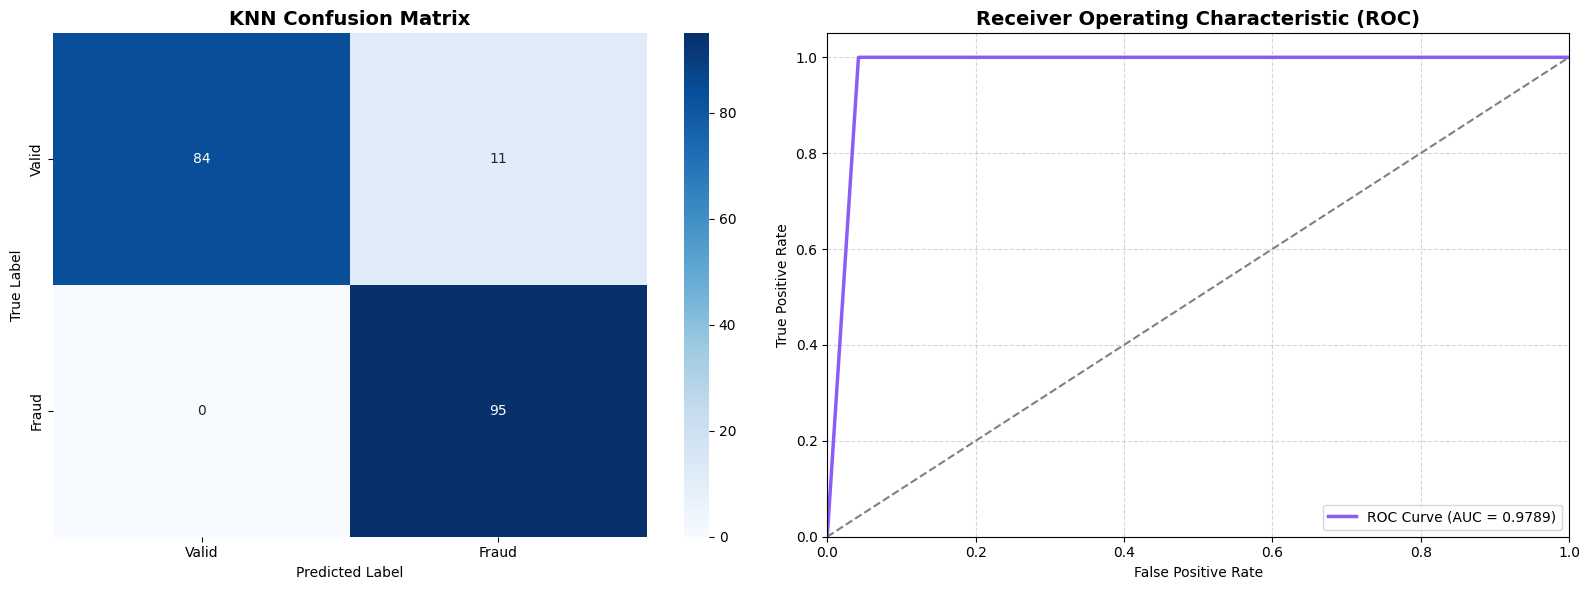

In [41]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# 1. Confusion Matrix Heatmap
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax[0], 
            xticklabels=['Valid', 'Fraud'], yticklabels=['Valid', 'Fraud'])
ax[0].set_title('KNN Confusion Matrix', fontsize=14, fontweight='bold')
ax[0].set_xlabel('Predicted Label')
ax[0].set_ylabel('True Label')

# 2. ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)
ax[1].plot(fpr, tpr, color='#8b5cf6', lw=2.5, label=f'ROC Curve (AUC = {roc_auc:.4f})')
ax[1].plot([0, 1], [0, 1], color='gray', linestyle='--')
ax[1].set_xlim([0.0, 1.0])
ax[1].set_ylim([0.0, 1.05])
ax[1].set_xlabel('False Positive Rate')
ax[1].set_ylabel('True Positive Rate')
ax[1].set_title('Receiver Operating Characteristic (ROC)', fontsize=14, fontweight='bold')
ax[1].legend(loc="lower right")
ax[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### Step 6: Parameter Tuning curve (n_neighbors vs F1-score)

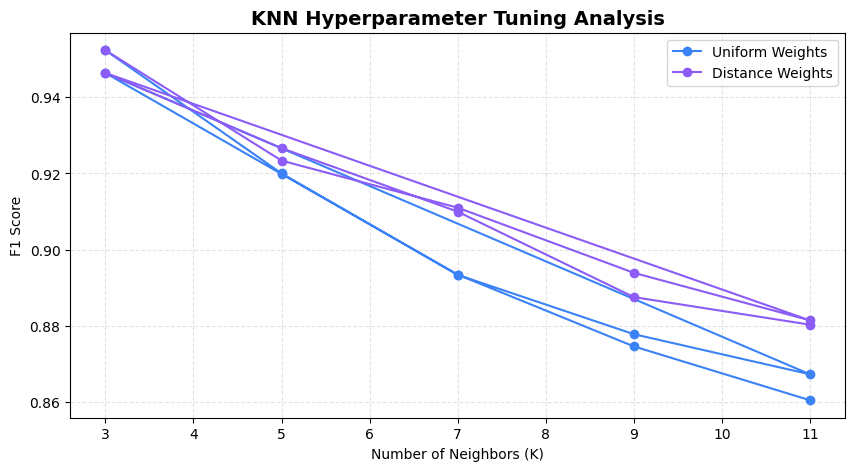

In [42]:
results = pd.DataFrame(grid_search.cv_results_)
uniform_results = results[results['param_weights'] == 'uniform']
distance_results = results[results['param_weights'] == 'distance']

plt.figure(figsize=(10, 5))
plt.plot(uniform_results['param_n_neighbors'], uniform_results['mean_test_score'], marker='o', label='Uniform Weights', color='#3b82f6')
plt.plot(distance_results['param_n_neighbors'], distance_results['mean_test_score'], marker='o', label='Distance Weights', color='#8b5cf6')
plt.title('KNN Hyperparameter Tuning Analysis', fontsize=14, fontweight='bold')
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('F1 Score')
plt.grid(True, linestyle='--', alpha=0.35)
plt.legend()
plt.show()